In [1]:
import torch
from torch import nn

torch.__version__

'2.7.1+cu118'

In [2]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
!nvidia-smi

Fri Jun 20 20:41:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   52C    P8              7W /   63W |     592MiB /   6144MiB |     38%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
#getting the data
from pathlib import Path
import requests
import zipfile

data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"

if image_path.is_dir():
    print("f{image_path} directory already exists ... skipping download")
else :
    print(f"{image_path} does note exist, creating one... ")
    image_path.mkdir(parents=True,exist_ok=True)

#download the data
with open(data_path/"pizza_steak_sushi.zip","wb") as f:
    request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading the file...")
    f.write(request.content)
#unzip the file
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
    print("unzipping data...")
    zip_ref.extractall(image_path)

f{image_path} directory already exists ... skipping download
unzipping data...


In [5]:
import os
def walk_through_dir(dir_path):
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"there are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [6]:
walk_through_dir(image_path)

there are 2 directories and 0 images in data\pizza_steak_sushi
there are 3 directories and 0 images in data\pizza_steak_sushi\test
there are 0 directories and 25 images in data\pizza_steak_sushi\test\pizza
there are 0 directories and 19 images in data\pizza_steak_sushi\test\steak
there are 0 directories and 31 images in data\pizza_steak_sushi\test\sushi
there are 3 directories and 0 images in data\pizza_steak_sushi\train
there are 0 directories and 78 images in data\pizza_steak_sushi\train\pizza
there are 0 directories and 75 images in data\pizza_steak_sushi\train\steak
there are 0 directories and 72 images in data\pizza_steak_sushi\train\sushi


In [7]:
train_dir=image_path/"train"
test_dir=image_path/"test"

test_dir,train_dir

(WindowsPath('data/pizza_steak_sushi/test'),
 WindowsPath('data/pizza_steak_sushi/train'))

In [8]:
import random
from PIL import Image

random.seed(42)
image_path_list=list(image_path.glob("*/*/*.jpg"))

image_path_list

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2218680.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2236338.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2508636.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2871261.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/3092704.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/309892.jp

In [9]:
# random.seed(42)
random_image_path=random.choice(image_path_list)
random_image_path

WindowsPath('data/pizza_steak_sushi/test/sushi/2394442.jpg')

In [10]:
image_class=random_image_path.parent.stem
image_class

'sushi'

random image path: data\pizza_steak_sushi\test\sushi\2394442.jpg
image class : sushi
image height : 408, image width : 512


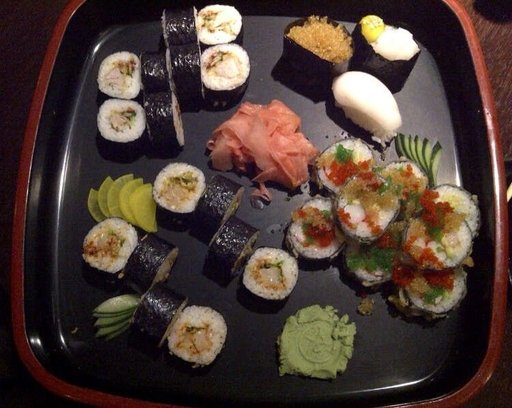

In [11]:
img=Image.open(random_image_path)

print(f"random image path: {random_image_path}")
print(f"image class : {image_class}")
print(f"image height : {img.height}, image width : {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(407.5), np.float64(-0.5))

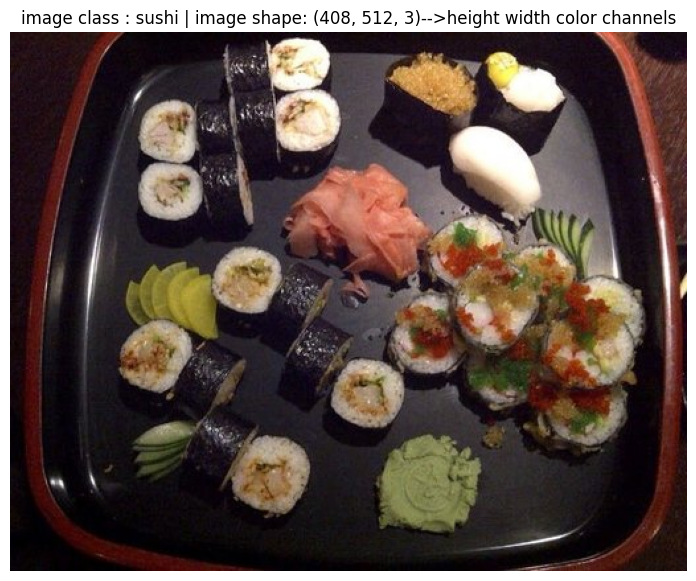

In [12]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array=np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"image class : {image_class} | image shape: {img_as_array.shape}-->height width color channels")
plt.axis(False)

In [13]:
img_as_array

array([[[33, 13, 15],
        [30, 10, 12],
        [30, 10, 12],
        ...,
        [23, 14, 19],
        [21, 12, 17],
        [20, 11, 16]],

       [[35, 15, 17],
        [32, 12, 14],
        [31, 11, 13],
        ...,
        [21, 12, 17],
        [19, 10, 15],
        [19, 10, 15]],

       [[34, 15, 17],
        [31, 12, 14],
        [30, 11, 13],
        ...,
        [19,  9, 17],
        [18,  8, 16],
        [18,  8, 16]],

       ...,

       [[11,  6, 12],
        [11,  6, 12],
        [11,  6, 12],
        ...,
        [33, 19, 18],
        [33, 19, 19],
        [31, 17, 17]],

       [[ 8,  3,  9],
        [ 9,  4, 10],
        [ 9,  4, 10],
        ...,
        [36, 21, 18],
        [32, 16, 16],
        [27, 11, 11]],

       [[ 4,  0,  5],
        [ 5,  0,  6],
        [ 6,  1,  7],
        ...,
        [36, 21, 18],
        [32, 16, 16],
        [25,  9,  9]]], shape=(408, 512, 3), dtype=uint8)

In [14]:
#now every img as an array(tensor)

import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [15]:
data_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [16]:
data_transform(img)

tensor([[[0.1294, 0.1373, 0.1412,  ..., 0.0863, 0.0824, 0.0824],
         [0.1255, 0.1373, 0.1412,  ..., 0.0902, 0.0902, 0.0902],
         [0.1294, 0.1412, 0.1333,  ..., 0.1059, 0.0980, 0.1137],
         ...,
         [0.0157, 0.0196, 0.0157,  ..., 0.1294, 0.1373, 0.1412],
         [0.0275, 0.0275, 0.0275,  ..., 0.1255, 0.1373, 0.1333],
         [0.0314, 0.0314, 0.0275,  ..., 0.1137, 0.1294, 0.1255]],

        [[0.0588, 0.0588, 0.0667,  ..., 0.0392, 0.0431, 0.0431],
         [0.0588, 0.0549, 0.0667,  ..., 0.0392, 0.0431, 0.0353],
         [0.0510, 0.0627, 0.0627,  ..., 0.0471, 0.0471, 0.0392],
         ...,
         [0.0039, 0.0078, 0.0078,  ..., 0.0667, 0.0667, 0.0667],
         [0.0118, 0.0118, 0.0118,  ..., 0.0706, 0.0706, 0.0667],
         [0.0118, 0.0157, 0.0196,  ..., 0.0667, 0.0667, 0.0667]],

        [[0.0667, 0.0667, 0.0667,  ..., 0.0706, 0.0706, 0.0745],
         [0.0784, 0.0784, 0.0863,  ..., 0.0941, 0.0902, 0.0863],
         [0.0824, 0.0863, 0.0941,  ..., 0.0941, 0.1059, 0.

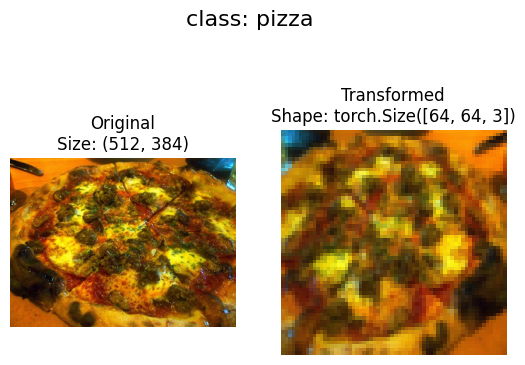

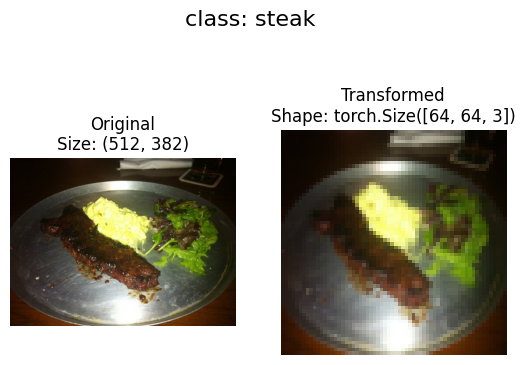

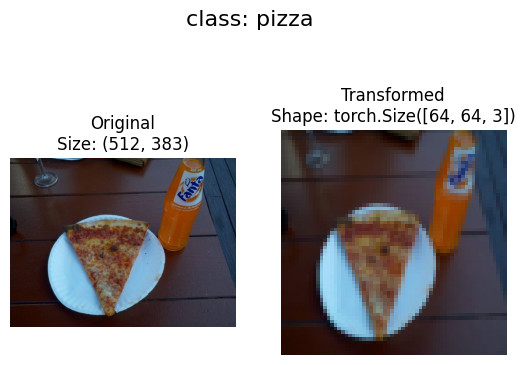

In [17]:
def plot_transformed_images(image_paths,transform,n=3,seed=42):
    if seed:
        random.seed(seed)
    random_image_paths=random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax=plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            transformed_image=transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"class: {image_path.parent.stem}",fontsize=16)
plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=420)

In [18]:
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                                transform=data_transform,
                                target_transform=None)


test_data=datasets.ImageFolder(root=test_dir,
                               transform=data_transform)

train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [19]:
class_names=train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [20]:
class_dict=train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [21]:
len(train_data),len(test_data)

(225, 75)

In [22]:
train_data.samples[0]

('data\\pizza_steak_sushi\\train\\pizza\\1008844.jpg', 0)

In [23]:
img,label=train_data[0][0],train_data[0][1]
print(f"image tensor:\n {img}")
print(f"image shape:{img.shape}")
print(f"image datatype:{img.dtype}")
print(f"image label:{label}")
print(f"label datatype:{type(label)}")

image tensor:
 tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0

original shape: torch.Size([3, 64, 64])
image permuted: torch.Size([64, 64, 3])


Text(0.5, 1.0, 'pizza')

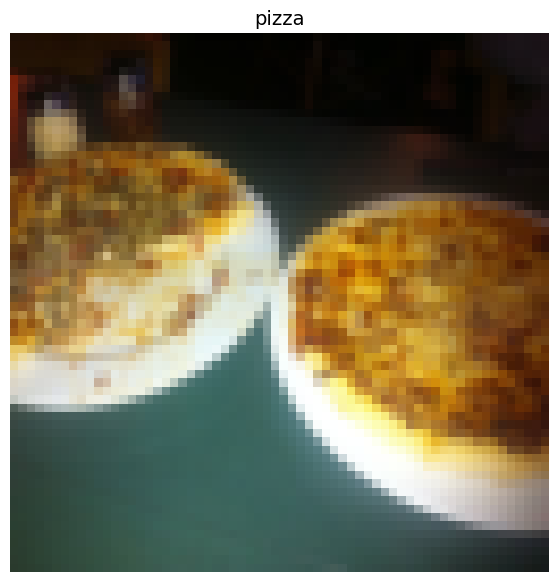

In [24]:
img_permute=img.permute(1,2,0)

print(f"original shape: {img.shape}")
print(f"image permuted: {img_permute.shape}")

plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label],fontsize=14)

In [25]:
import os
os.cpu_count()

16

In [26]:
from torch.utils.data import DataLoader
BATCH_SIZE=1
train_dataloader=DataLoader(dataset=train_data,
                            batch_size=BATCH_SIZE,
                            num_workers=os.cpu_count(),
                            shuffle=True
                            )
test_dataloader=DataLoader(dataset=test_data,
                           batch_size=BATCH_SIZE,
                           num_workers=os.cpu_count(),
                           shuffle=False)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1a337370470>,
 <torch.utils.data.dataloader.DataLoader at 0x1a33719f020>)

In [27]:
len(train_dataloader),len(test_dataloader)

(225, 75)

In [28]:
img,label=next(iter(train_dataloader))

print(f"image shape: {img.shape}")
print(f"lablel shape: {label.shape}")

image shape: torch.Size([1, 3, 64, 64])
lablel shape: torch.Size([1])


In [29]:
#option 2 loading image data with a custom dataset

import os 
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict,List

In [30]:
train_data.classes,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [31]:
#creating a helper ffuction to get the output as above 

target_directory=train_dir
print(f"Target directory: {target_directory}")

class_names_found=sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target directory: data\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [32]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [33]:
def find_classes(directory: str)->Tuple[List[str],Dict[str,int]]:
    classes=sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"Couldnt find any classes in {directory}...")
    

    class_to_idx={class_name: i for i ,class_name in enumerate(classes)}
    

    return classes,class_to_idx

In [34]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [35]:
#custom dataset
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):
    def __init__(self,
                 targ_dir:str,
                 transform=None):
        self.paths=list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        self.transform=transform

        self.classes,self.class_to_idx=find_classes(targ_dir)

    def load_image(self,index:int)->Image.Image:
        image_path=self.paths[index]
        return Image.open(image_path)
    
    def __len__(self)->int:
        return len(self.paths)
    
    def __getitem__(self,index:int)->Tuple[torch.Tensor,int]:
        img=self.load_image(index)
        class_name=self.paths[index].parent.name
        class_idx=self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img),class_idx
        else: 
            return img,class_idx


In [36]:
train_transforms=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [37]:
train_data_custom=ImageFolderCustom(targ_dir=train_dir,
                                    transform=train_transforms)

test_data_custom=ImageFolderCustom(targ_dir=test_dir,
                                   transform=test_transforms)

In [38]:
train_data_custom,test_data_custom

(<__main__.ImageFolderCustom at 0x1a3370dec30>,
 <__main__.ImageFolderCustom at 0x1a33741cda0>)

In [39]:
len(train_data),len(train_data_custom)

(225, 225)

In [40]:
len(test_data),len(test_data_custom)

(75, 75)

In [41]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [42]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [43]:
print(train_data_custom.classes==train_data.classes)
print(test_data_custom.classes==test_data.classes)

True
True


In [44]:
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes:List[str]=None,
                          n:int=10,
                          display_shape:bool=True,
                          seed:int=None):
    if n>10:
        n=10
        display_shape=False
        print(f"For disply,purposes n shouldnt be large than 10m setting to 10 and removing shape display.")
    if seed:
        random.seed(seed)
    

    random_sample_idx=random.sample(range(len(dataset)),k=n)

    plt.figure(figsize=(16,8))

    for i, targ_sample in enumerate(random_sample_idx):
        targ_image,targ_label=dataset[targ_sample][0],dataset[targ_sample][1]

        targ_image_adjust=targ_image.permute(1,2,0)

        plt.subplot(1,n,i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title=f"class: {classes[targ_label]}"
            if display_shape:
                title=title+f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)
        

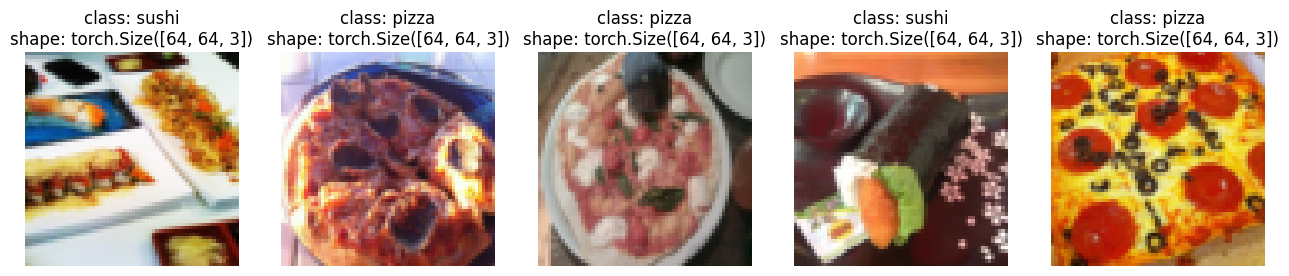

In [45]:
display_random_images(train_data_custom,
                      n=5,
                      classes=class_names,
                      seed=42)

In [46]:
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader_custom=DataLoader(dataset=train_data_custom,
                                   batch_size=BATCH_SIZE,
                                   num_workers=0,
                                   shuffle=True)

test_dataloader_custom=DataLoader(dataset=test_data_custom,
                                  batch_size=BATCH_SIZE,
                                  num_workers=os.cpu_count(),
                                  shuffle=False)

train_dataloader_custom,test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x1a3372adca0>,
 <torch.utils.data.dataloader.DataLoader at 0x1a3372aee70>)

In [47]:
img_custom,label_custom=next(iter(train_dataloader_custom))

img_custom.shape,label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [48]:
#data augmentation
#trivial augment
from torchvision import transforms

train_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [49]:
image_path_list=list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg')]

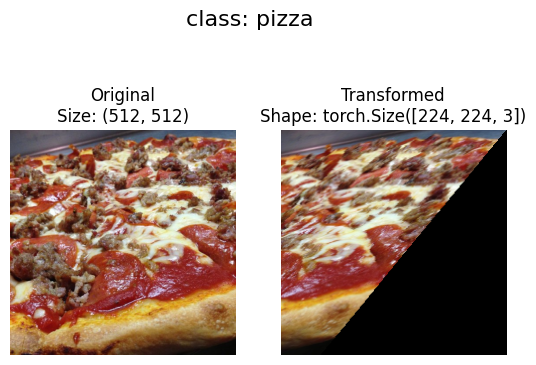

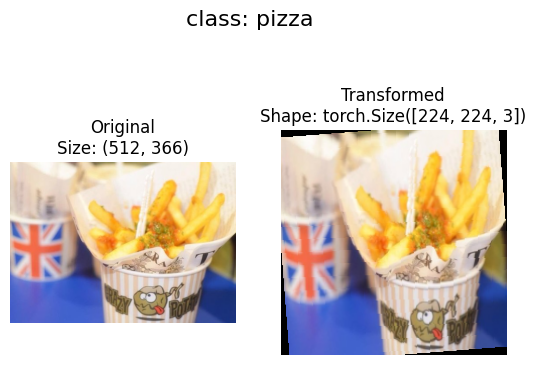

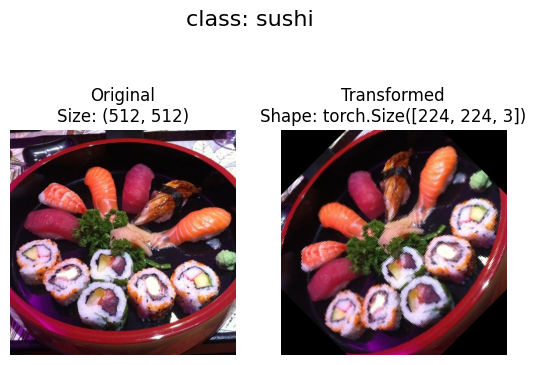

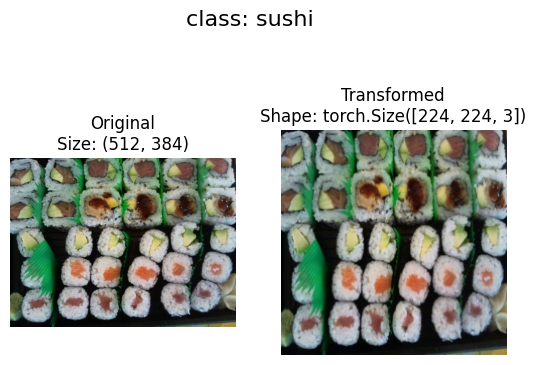

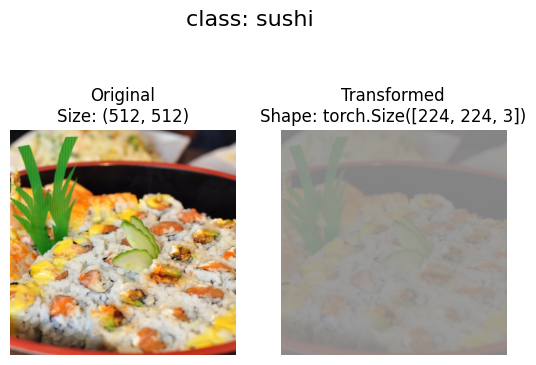

In [50]:
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transform,
    n=5,
    seed=None
)

# Creating the model

In [51]:
#tinyvgg creating the model from scratch

simple_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [52]:
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)
test_data_simple=datasets.ImageFolder(root=test_dir,
                                      transform=simple_transform)



import os
from torch.utils.data import DataLoader

BATCH_SIZE=32
NUM_WORKERS=os.cpu_count()

train_dataloader_simple=DataLoader(dataset=train_data_simple,
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=0)
test_dataloader_simple=DataLoader(dataset=test_data_simple,
                                  batch_size=BATCH_SIZE,
                                  shuffle=False,
                                  num_workers=0)

In [53]:
class TinyVGG(nn.Module):
    def __init__(self,
                 input_shape:int,
                 hidden_units:int,
                 output_shape:int)->None:
        super().__init__()
        self.conv_block_1=nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.conv_block_2=nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )
    def forward(self,x):
        x=self.conv_block_1(x)
        # print(x.shape)
        x=self.conv_block_2(x)
        # print(x.shape)
        x=self.classifier(x)
        # print(x.shape)
        return x

In [54]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of color channels in our image data
                  hidden_units=50, 
                  output_shape=len(class_names)).to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(50, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(50, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(50, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12800, out_features=3, bias=True)
  )
)

In [55]:
image_batch,label_batch=next(iter(train_dataloader_simple))
image_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [56]:
model_0(image_batch.to(device))
#there will be an error this is to find the right shape for the hidden unit in the conv_block_2

tensor([[-0.0352,  0.0113,  0.0214],
        [-0.0310, -0.0013,  0.0207],
        [-0.0373,  0.0099,  0.0199],
        [-0.0295,  0.0008,  0.0216],
        [-0.0359,  0.0042,  0.0209],
        [-0.0351,  0.0004,  0.0125],
        [-0.0410,  0.0037,  0.0202],
        [-0.0358,  0.0081,  0.0198],
        [-0.0367,  0.0015,  0.0170],
        [-0.0342, -0.0006,  0.0182],
        [-0.0382,  0.0044,  0.0204],
        [-0.0384,  0.0033,  0.0196],
        [-0.0358,  0.0045,  0.0176],
        [-0.0325,  0.0009,  0.0183],
        [-0.0348,  0.0039,  0.0187],
        [-0.0296, -0.0057,  0.0135],
        [-0.0317,  0.0079,  0.0219],
        [-0.0333,  0.0037,  0.0215],
        [-0.0295,  0.0025,  0.0163],
        [-0.0378,  0.0014,  0.0179],
        [-0.0382,  0.0117,  0.0233],
        [-0.0300,  0.0046,  0.0195],
        [-0.0345,  0.0002,  0.0132],
        [-0.0317,  0.0020,  0.0173],
        [-0.0394,  0.0072,  0.0152],
        [-0.0346,  0.0015,  0.0193],
        [-0.0366,  0.0116,  0.0250],
 

In [57]:
import torchinfo
from torchinfo import summary
summary(model_0,input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 50, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 50, 64, 64]           1,400
│    └─ReLU: 2-2                         [1, 50, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 50, 64, 64]           22,550
│    └─ReLU: 2-4                         [1, 50, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 50, 32, 32]           --
├─Sequential: 1-2                        [1, 50, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 50, 32, 32]           22,550
│    └─ReLU: 2-7                         [1, 50, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 50, 32, 32]           22,550
│    └─ReLU: 2-9                         [1, 50, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 50, 16, 16]           --


In [58]:
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device=device):
    
    model.train()

    train_loss,train_acc=0,0

    for batch,(X,y) in enumerate(dataloader):
        X,y=X.to(device),y.to(device)

        y_pred=model(X)

        loss=loss_fn(y_pred,y)
        train_loss+=loss.item()

        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
        train_acc+=(y_pred_class==y).sum().item()/len(y_pred)

    train_loss=train_loss/len(dataloader)
    train_acc=train_acc/len(dataloader)
    return train_loss,train_acc

In [59]:
def test_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               device=device):
    model.eval()

    test_loss,test_acc=0,0
    with torch.inference_mode():
        for batch,(X,y) in enumerate(dataloader):
            X,y=X.to(device),y.to(device)

            test_pred_logits=model(X)

            loss=loss_fn(test_pred_logits,y)
            test_loss+=loss.item()

            test_pred_labels=test_pred_logits.argmax(dim=1)
            test_acc+=((test_pred_labels==y).sum().item()/len(test_pred_labels))
    test_loss=test_loss/len(dataloader)
    test_acc=test_acc/len(dataloader)
    return test_loss,test_acc

In [60]:
import torch.optim.optimizer
from tqdm.auto import tqdm

def train(model:torch.nn.Module,
          train_dataloader:torch.utils.data.DataLoader,
          test_dataloader:torch.utils.data.DataLoader,
          optimizer:torch.optim.Optimizer,
          loss_fn:torch.nn.Module=nn.CrossEntropyLoss(),
          epochs:int=5,
          device=device):
    results={"train_loss":[],
            "train_acc":[],
            "test_loss":[],
            "test_acc":[]}
    for epoch in tqdm(range(epochs)):
        train_loss,train_acc=train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )
        test_loss,test_acc=test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device
        )

        print(f"Epochs: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

C:\Users\Priyanshu\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [62]:
#train and evaluate the model_0

torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS=10

model_0=TinyVGG(input_shape=3,#no. of color channels in the image
                hidden_units=10,
                output_shape=len(train_data.classes)).to(device)


loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(),
                           lr=0.001)


from timeit import default_timer as timer
start_time=timer()

model_0_results=train(model=model_0,
                      train_dataloader=train_dataloader_simple,
                      test_dataloader=test_dataloader_simple,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS)

end_time=timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")



 10%|█         | 1/10 [00:01<00:09,  1.04s/it]

Epochs: 0 | Train loss: 1.1078 | Train acc: 0.2578 | Test loss: 1.1362 | Test acc: 0.2604


 20%|██        | 2/10 [00:01<00:06,  1.18it/s]

Epochs: 1 | Train loss: 1.0846 | Train acc: 0.4258 | Test loss: 1.1622 | Test acc: 0.1979


 30%|███       | 3/10 [00:02<00:05,  1.31it/s]

...

Epochs: 7 | Train loss: 1.1010 | Train acc: 0.3672 | Test loss: 1.1039 | Test acc: 0.2188


 90%|█████████ | 9/10 [00:06<00:00,  1.39it/s]

Epochs: 8 | Train loss: 1.0877 | Train acc: 0.4883 | Test loss: 1.0640 | Test acc: 0.5417


100%|██████████| 10/10 [00:07<00:00,  1.36it/s]

Epochs: 9 | Train loss: 1.0653 | Train acc: 0.4023 | Test loss: 1.0156 | Test acc: 0.5417
Total training time: 7.361 seconds


In [63]:
model_0_results

{'train_loss': [1.1078362166881561,
  1.084640771150589,
  1.115250751376152,
  1.0995756685733795,
  1.0988245010375977,
  1.0966534167528152,
  1.1185872256755829,
  1.1010087579488754,
  1.0876980125904083,
  1.065347507596016],
 'train_acc': [0.2578125,
  0.42578125,
  0.29296875,
  0.2890625,
  0.29296875,
  0.3125,
  0.32421875,
  0.3671875,
  0.48828125,
  0.40234375],
 'test_loss': [1.136200229326884,
  1.1621737082799275,
  1.1693156560262044,
  1.133494774500529,
  1.1436883211135864,
  1.148279865582784,
  1.1422570546468098,
  1.1039104859034221,
  1.0640418132146199,
  1.0156299670537312],
 'test_acc': [0.2604166666666667,
  0.19791666666666666,
  0.19791666666666666,
  0.21875,
  0.19791666666666666,
  0.2604166666666667,
  0.2916666666666667,
  0.21875,
  0.5416666666666666,
  0.5416666666666666]}

In [64]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

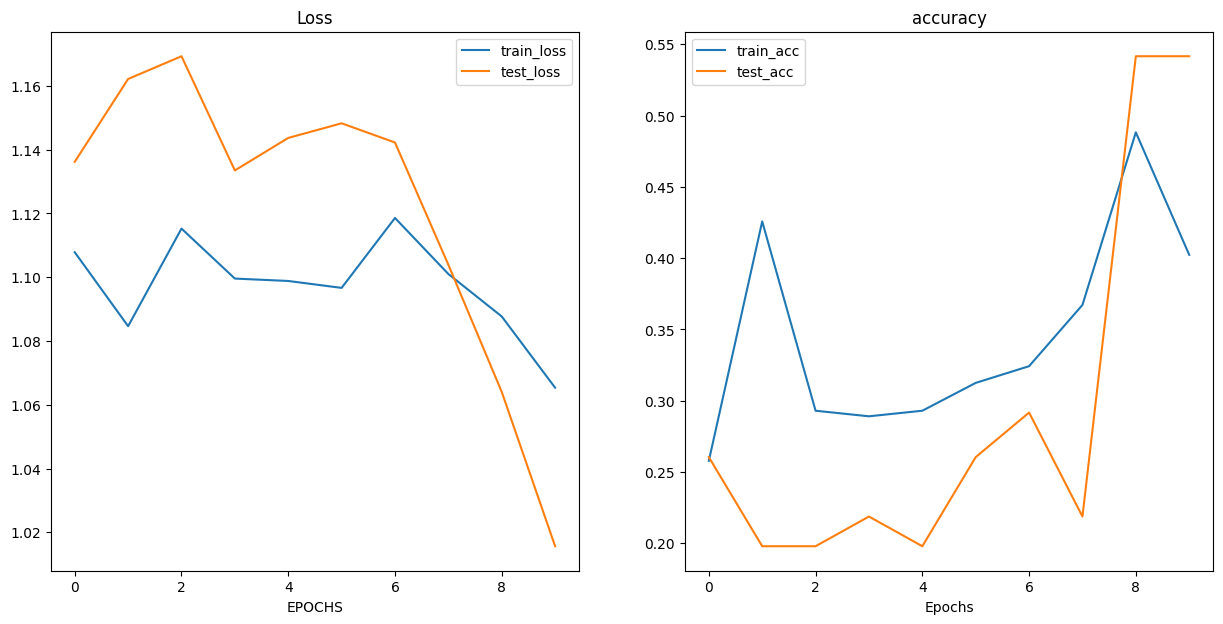

In [65]:
def plot_loss_curves(results:Dict[str,List[float]]):
    loss=results["train_loss"]
    test_loss=results["test_loss"]

    accuracy=results["train_acc"]
    test_accuracy=results["test_acc"]

    epochs=range(len(results["train_loss"]))

    plt.figure(figsize=(15,7))

    plt.subplot(1,2,1)

    plt.plot(epochs,loss,label="train_loss")
    plt.plot(epochs,test_loss,label="test_loss")
    plt.title("Loss")
    plt.xlabel("EPOCHS")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs,accuracy,label="train_acc")
    plt.plot(epochs,test_accuracy,label="test_acc")
    plt.title("accuracy")
    plt.xlabel("Epochs")
    plt.legend()




plot_loss_curves(model_0_results)

In [66]:
#there is some problem with the model it is under or overfitting.
#i think it is a overfitting but the github copilot is telling it is underfitting.
#lets try data augmentation for overfitting problem
#trying the second model

from torchvision import transforms
train_transform_trivial=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [67]:
#dataset and dataloader
from torchvision import datasets
train_data_augmented=datasets.ImageFolder(root=train_dir,
                                          transform=train_transform_trivial)
test_data_simple=datasets.ImageFolder(root=test_dir,
                                      transform=test_transform_simple)

In [68]:
import os
from torch.utils.data import DataLoader
BATCH_SIZE=32
NUM_WORKERS=0
torch.manual_seed(42)
train_dataloader_augmented=DataLoader(dataset=train_data_augmented,
                                      batch_size=BATCH_SIZE,
                                      shuffle=True,
                                      num_workers=NUM_WORKERS)
test_dataloader_augmented=DataLoader(dataset=test_data_simple,
                                      batch_size=BATCH_SIZE,
                                      shuffle=False,
                                      num_workers=NUM_WORKERS)

In [111]:
torch.manual_seed(42)
model_1=TinyVGG(input_shape=3,
                hidden_units=10,
                output_shape=len(train_data_augmented.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [112]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS=10

loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_1.parameters(),
                           lr=0.001)

from timeit import default_timer as timer

start_time=timer()

model_1_results=train(model=model_1,
                      train_dataloader=train_dataloader_augmented,
                      test_dataloader=test_dataloader_augmented,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS,
                      device=device)


end_time=timer()
print(f"total training time for model_1: {end_time-start_time} seconds.")


 10%|█         | 1/10 [00:00<00:08,  1.01it/s]

Epochs: 0 | Train loss: 1.1067 | Train acc: 0.2422 | Test loss: 1.1081 | Test acc: 0.2604


 20%|██        | 2/10 [00:01<00:06,  1.24it/s]

Epochs: 1 | Train loss: 1.0754 | Train acc: 0.4258 | Test loss: 1.1517 | Test acc: 0.2604


 30%|███       | 3/10 [00:02<00:05,  1.29it/s]

...

Epochs: 7 | Train loss: 1.0846 | Train acc: 0.4258 | Test loss: 1.0975 | Test acc: 0.2604


 90%|█████████ | 9/10 [00:07<00:00,  1.16it/s]

Epochs: 8 | Train loss: 1.1157 | Train acc: 0.3047 | Test loss: 1.1156 | Test acc: 0.2604


100%|██████████| 10/10 [00:08<00:00,  1.16it/s]

Epochs: 9 | Train loss: 1.0810 | Train acc: 0.4570 | Test loss: 1.1337 | Test acc: 0.2708
total training time for model_1: 8.635016900021583 seconds.


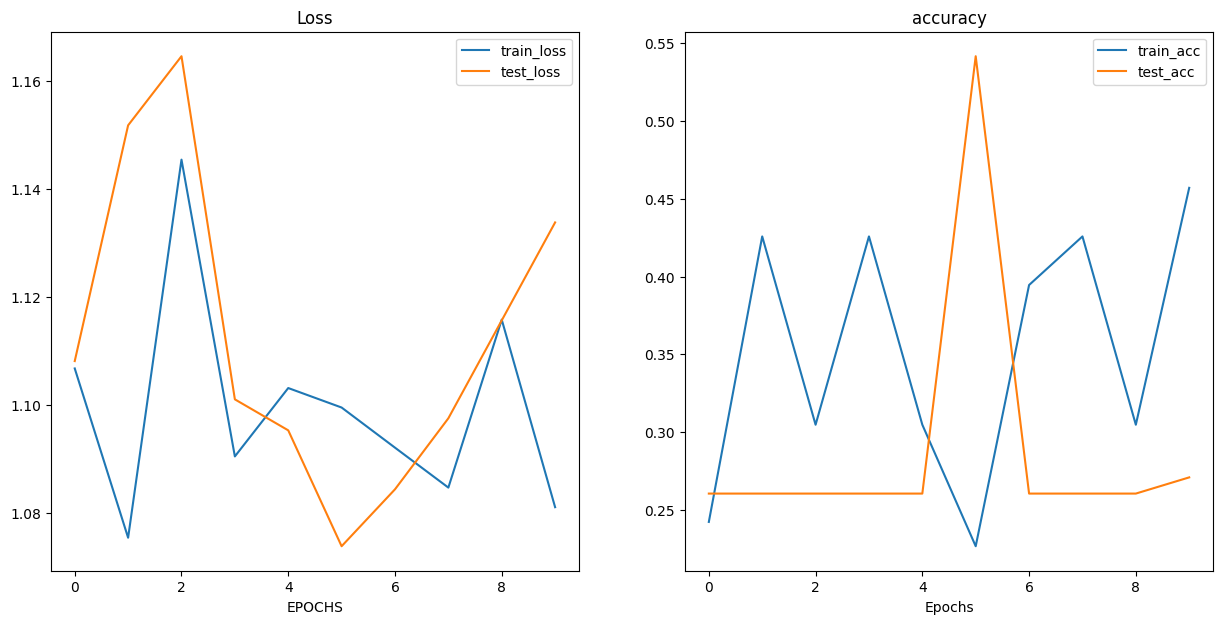

In [113]:
plot_loss_curves(model_1_results)

In [72]:
#there is more variation when we use data augmentaion


In [114]:
import pandas as pd

model_0_df=pd.DataFrame(model_0_results)
model_1_df=pd.DataFrame(model_1_results)

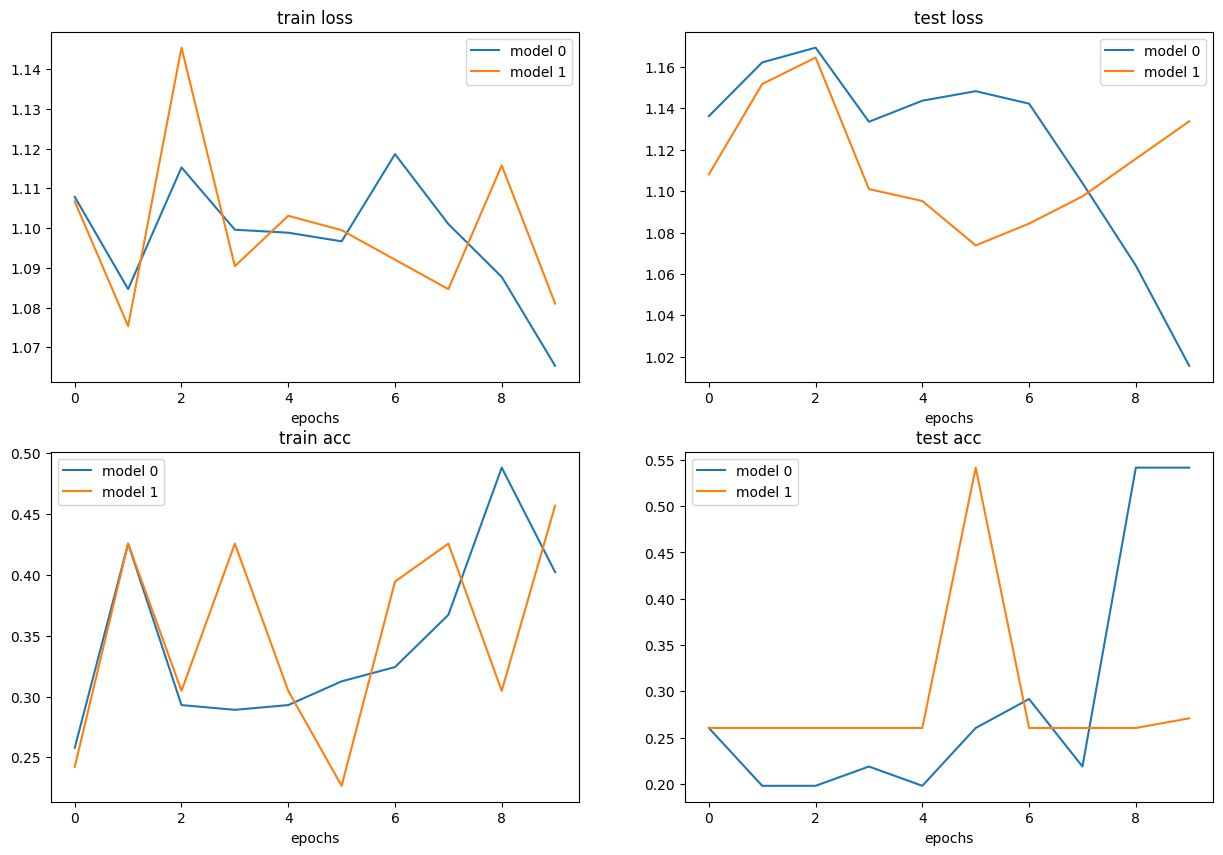

In [115]:
plt.figure(figsize=(15,10))

epochs=range(len(model_0_df))

plt.subplot(2,2,1)
plt.plot(epochs,model_0_df["train_loss"],label="model 0")
plt.plot(epochs,model_1_df["train_loss"],label="model 1")
plt.title("train loss")
plt.xlabel("epochs")
plt.legend()

plt.subplot(2,2,2)
plt.plot(epochs,model_0_df["test_loss"],label="model 0")
plt.plot(epochs,model_1_df["test_loss"],label="model 1")
plt.title("test loss")
plt.xlabel("epochs")
plt.legend()

plt.subplot(2,2,3)
plt.plot(epochs,model_0_df["train_acc"],label="model 0")
plt.plot(epochs,model_1_df["train_acc"],label="model 1")
plt.title("train acc")
plt.xlabel("epochs")
plt.legend()

plt.subplot(2,2,4)
plt.plot(epochs,model_0_df["test_acc"],label="model 0")
plt.plot(epochs,model_1_df["test_acc"],label="model 1")
plt.title("test acc")
plt.xlabel("epochs")
plt.legend()

In [116]:
#making a prediction using the model
import requests

custom_image_path=data_path/"custom_image.png"
custom_image_path

WindowsPath('data/custom_image.png')

In [117]:
#loading the custom image

import torchvision 
custom_image_uint8=torchvision.io.read_image(custom_image_path)
custom_image_uint8

tensor([[[255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         ...,
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44]],

        [[255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         ...,
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44]],

        [[255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         ...,
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [25

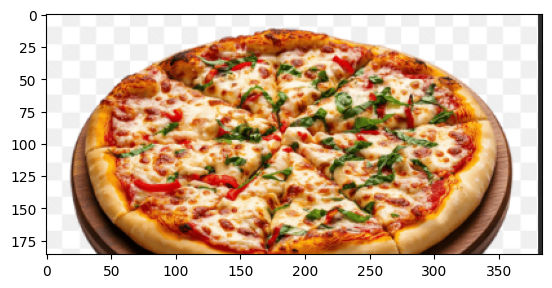

In [118]:
plt.imshow(custom_image_uint8.permute(1,2,0))

In [119]:
print(f"custom image tensor:\n {custom_image_uint8}")
print(f"custom image shape: {custom_image_uint8.shape}")
print(f"custom image datatype: {custom_image_uint8.dtype}")


custom image tensor:
 tensor([[[255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         ...,
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44]],

        [[255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         ...,
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44]],

        [[255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         ...,
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44],
         [255, 255, 255,  ...,  44,  44,  44]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 2

In [120]:
#as it has alpha channel because of the transperency we have to reduce the image from 4 to 3 channels 
custom_image_uint8 = custom_image_uint8[:3, :, :]



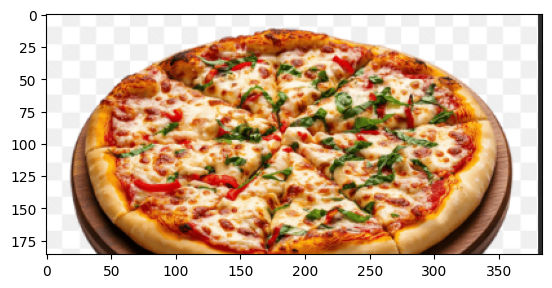

In [121]:
plt.imshow(custom_image_uint8.permute(1,2,0))

In [122]:
custom_image_uint8.shape

torch.Size([3, 186, 384])

In [ ]:
#different datatype
model_1.eval()
with torch.inference_mode():
    model_1(custom_image_uint8.to(device))

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

In [124]:
#here the datatype is wrong we want torch.cuda.float.tensor

custom_image=torchvision.io.read_image(str(custom_image_path)).type(torch.float32)/255
custom_image=custom_image[:3,:,:]
print(custom_image.shape)
custom_image

torch.Size([3, 186, 384])


tensor([[[1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725]],

        [[1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725]],

        [[1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.1725],
         [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1725, 0.

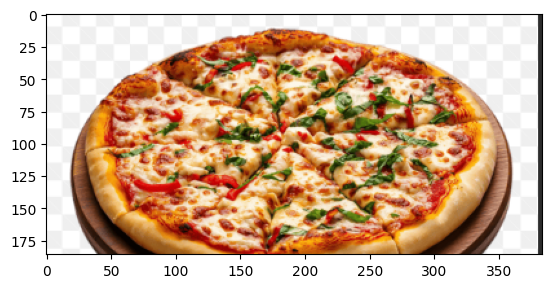

In [125]:
plt.imshow(custom_image.permute(1,2,0))

In [126]:
model_1.eval()
with torch.inference_mode():
    model_1(custom_image.to(device))
    

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x4416 and 2560x3)

In [127]:
#now the problem is the shape convert it to 64x64

custom_image_transform=transforms.Compose([
    transforms.Resize(size=(64,64))
])
custom_image_transformed=custom_image_transform(custom_image)
custom_image_transformed.shape

torch.Size([3, 64, 64])

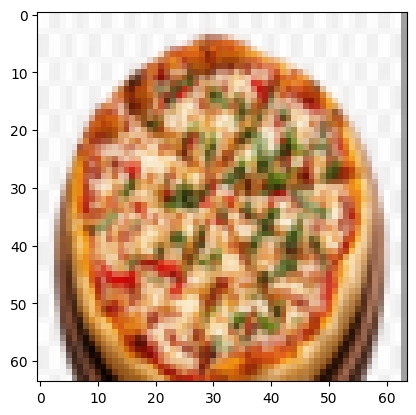

In [128]:
plt.imshow(custom_image_transformed.permute(1,2,0))

In [ ]:
#not batch size thats why error in the shape of mat1,mat2
model_1.eval()
with torch.inference_mode():
    model_1(custom_image_transformed.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x256 and 2560x3)

In [130]:
model_1.eval()
with torch.inference_mode():
    custom_image_pred=model_1(custom_image_transformed.unsqueeze(0).to(device))
custom_image_pred

tensor([[ 0.0532,  0.0290, -0.1336]], device='cuda:0')

In [131]:
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [133]:
custom_image_pred_probs=torch.softmax(custom_image_pred,dim=1)
custom_image_pred_probs

tensor([[0.3564, 0.3479, 0.2957]], device='cuda:0')

In [134]:
custom_image_pred_labels=torch.argmax(custom_image_pred_probs,dim=1)
class_names[custom_image_pred_labels]

'pizza'

In [141]:
#making the fuction of predicting a custom image from any where


def pred_plot_image(model:torch.nn.Module,
                    image_path:str,
                    class_names:List[str]=None,
                    transform=None,
                    device=device):
    target_image=torchvision.io.read_image(str(image_path)).type(torch.float32)
    target_image=target_image[:3,:,:]#because of the transperancy
    target_image=target_image/255.
    if transform:
        target_image=transform(target_image)

    model.to(device)
    model.eval()
    with torch.inference_mode():
        target_image=target_image.unsqueeze(0)
        target_image_pred=model(target_image.to(device))
    target_image_pred_probs=torch.softmax(target_image_pred,dim=1)
    target_image_pred_label=torch.argmax(target_image_pred_probs,dim=1)
    plt.imshow(target_image.squeeze().permute(1,2,0))
    if class_names:
        title=f"pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title=f"Pred:{target_image_pred_label} | Prob:{target_image_pred_probs.max().cpu:.3f}"
    plt.title(title)
    plt.axis(False)
    

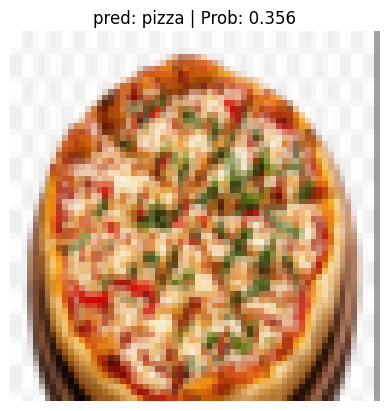

In [144]:
pred_plot_image(model=model_1,
                image_path=custom_image_path,
                class_names=class_names,
                transform=custom_image_transform,
                device=device)

# EXCERCISE

In [13]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.7.1+cu118


'cuda'

In [14]:
import requests
import zipfile
from pathlib import Path

data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find the directory ,creating")
    image_path.mkdir(parents=True,exist_ok=True)


#this is already dowloaded so not doing it again 
# with open(data_path/"pizza_steak_sushi.zip","wb") as f:
#     request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
#     print("downloading pizza steak sushi data")
#     f.write(request.content)
# with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as f:
#     print(f"Unzipping pizza steak sushi data to {image_path}")
#     zip_ref.extractall(image_path)

data\pizza_steak_sushi directory exists.


In [15]:
import os 
def walk_throuhg_dir(dir_path):
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")


In [16]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [17]:
train_dir=image_path/"train"
test_dir=image_path/"test"


[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'), WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'), WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg')]
sushi
Random image path: data\pizza_steak_sushi\test\sushi\1680893.jpg
Image class: sushi
Image height: 512
Image width: 512


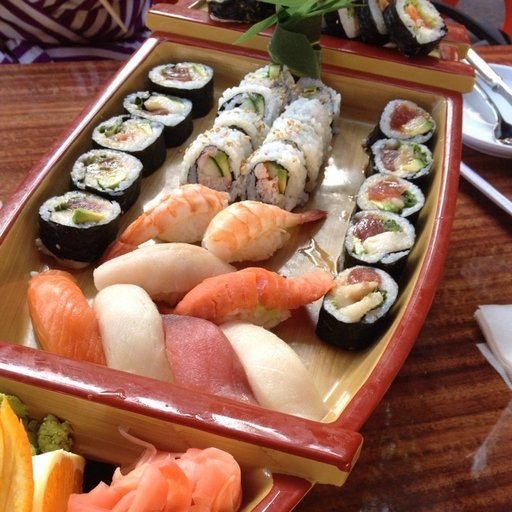

In [19]:
import random 
from PIL import Image

image_path_list=list(image_path.glob("*/*/*.jpg"))
print(image_path_list[:3])
random_image_path=random.choice(image_path_list)

image_class=random_image_path.parent.stem
print(image_class)

img=Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

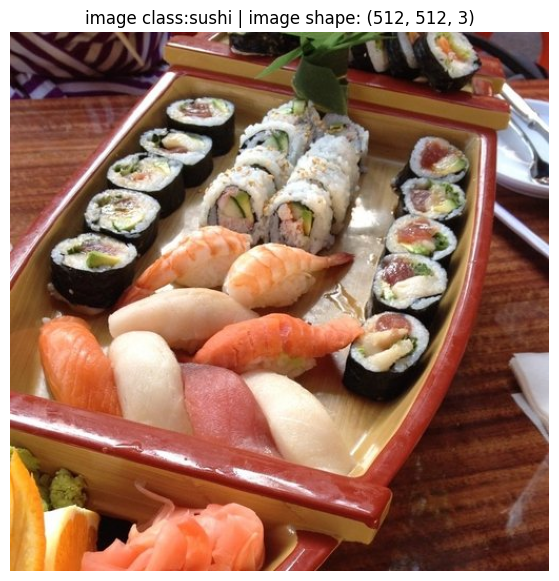

In [20]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array=np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"image class:{image_class} | image shape: {img_as_array.shape}")
plt.axis(False)

In [21]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [22]:
data_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [23]:
random.sample(image_path_list,k=3)

[WindowsPath('data/pizza_steak_sushi/train/steak/937133.jpg'),
 WindowsPath('data/pizza_steak_sushi/train/steak/3518960.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/3092704.jpg')]

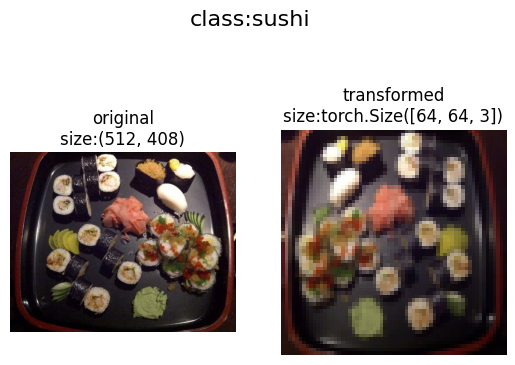

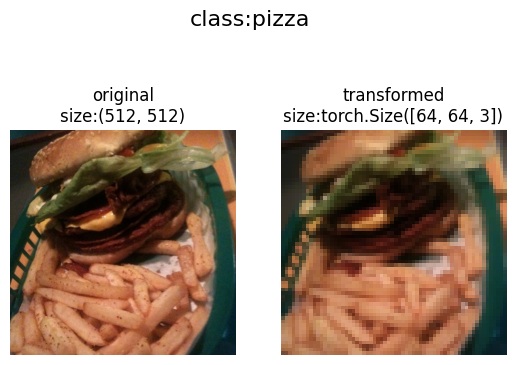

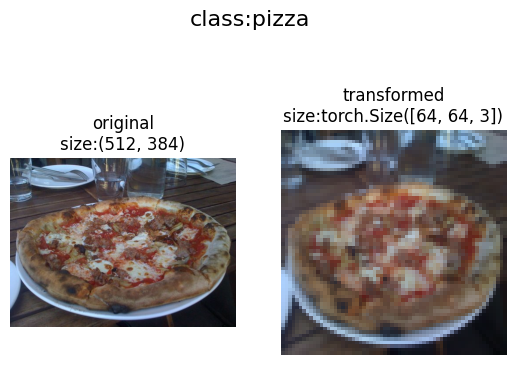

In [28]:
def plot_transformed_images(image_paths,transform,n=3,seed=42):
    random.seed(seed)
    random_image_paths=random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax=plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"original\nsize:{f.size}")
            ax[0].axis("off")

            transformed_image=transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"transformed\nsize:{transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"class:{image_path.parent.stem}",fontsize=16)
plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)

In [ ]:
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                                transform=data_transform,
                                target_transform=None)
test_data=datasets.ImageFolder(root=test_dir,
                               transform=data_transform,
                               target_transform=None)
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [31]:
class_names=train_data.classes
class_dict=train_data.class_to_idx
class_names,class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [32]:
from torch.utils.data import DataLoader
BATCH_SIZE=1
train_dataloader=DataLoader(dataset=train_data,
                            batch_size=BATCH_SIZE,
                            num_workers=2,
                            shuffle=True)
test_dataloader=DataLoader(dataset=test_data,
                           batch_size=BATCH_SIZE,
                           num_workers=2,
                           shuffle=False)

In [33]:
img,label=next(iter(train_dataloader))

print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


In [34]:
import torch
from torch import nn

class TinyVGG(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*16*16,
                  out_features=output_shape))
        
  def forward(self, x):
    x = self.conv_block_1(x)
    # print(f"Layer 1 shape: {x.shape}")
    x = self.conv_block_2(x)
    # print(f"Layer 2 shape: {x.shape}")
    x = self.classifier(x)
    # print(f"Layer 3 shape: {x.shape}")
    return x

In [35]:
model_ex=TinyVGG(input_shape=3,
                 hidden_units=10,
                 output_shape=len(class_names)).to(device)
model_ex

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [36]:
dummy_x = torch.rand(size=[1, 3, 64, 64])
model_ex(dummy_x.to(device))

tensor([[-6.0213e-05,  3.0915e-02,  4.2651e-02]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [37]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  
  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for batch, (X, y) in enumerate(dataloader):
    # Send data to target device
    X, y = X.to(device), y.to(device) 

    # 1. Forward pass
    y_pred = model(X)
    # print(y_pred)

    # 2. Calculate and accumulate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad 
    optimizer.zero_grad()

    # 4. Loss backward 
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate and accumualte accuracy metric across all batches
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust metrics to get average loss and average accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc 

In [38]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  
  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
    # Loop through DataLoader batches
    for batch, (X, y) in enumerate(dataloader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X)
      # print(test_pred_logits)

      # 2. Calculuate and accumulate loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Calculate and accumulate accuracy
      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
    
  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

In [39]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
  
  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model, 
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model, 
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
    
    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

C:\Users\Priyanshu\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model_ex.parameters(),lr=0.001)
model_ex_resutls=train(model=model_ex,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       epochs=5)

 20%|██        | 1/5 [00:08<00:32,  8.19s/it]

Epoch: 1 | train_loss: 1.1214 | train_acc: 0.3422 | test_loss: 1.0991 | test_acc: 0.2533


 40%|████      | 2/5 [00:15<00:23,  7.93s/it]

Epoch: 2 | train_loss: 1.0672 | train_acc: 0.4044 | test_loss: 1.1912 | test_acc: 0.3200


 60%|██████    | 3/5 [00:23<00:15,  7.86s/it]

Epoch: 3 | train_loss: 1.0134 | train_acc: 0.5600 | test_loss: 0.9979 | test_acc: 0.4400


 80%|████████  | 4/5 [00:31<00:07,  7.89s/it]

Epoch: 4 | train_loss: 0.9398 | train_acc: 0.5644 | test_loss: 1.0125 | test_acc: 0.4000


100%|██████████| 5/5 [00:39<00:00,  7.92s/it]

Epoch: 5 | train_loss: 0.9111 | train_acc: 0.5822 | test_loss: 0.9777 | test_acc: 0.4267


In [41]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_ex_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ex_1.parameters(), lr=0.001)

model_1_results = train(model=model_ex_1,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        epochs=20)

  5%|▌         | 1/20 [00:07<02:29,  7.89s/it]

Epoch: 1 | train_loss: 1.1179 | train_acc: 0.2800 | test_loss: 1.0959 | test_acc: 0.4000


 10%|█         | 2/20 [00:15<02:20,  7.80s/it]

Epoch: 2 | train_loss: 1.1011 | train_acc: 0.3244 | test_loss: 1.0996 | test_acc: 0.2533


 15%|█▌        | 3/20 [00:23<02:12,  7.80s/it]

...

Epoch: 18 | train_loss: 1.1001 | train_acc: 0.3378 | test_loss: 1.1040 | test_acc: 0.3333


 95%|█████████▌| 19/20 [02:27<00:07,  7.74s/it]

Epoch: 19 | train_loss: 1.0947 | train_acc: 0.3511 | test_loss: 1.0869 | test_acc: 0.3733


100%|██████████| 20/20 [02:34<00:00,  7.74s/it]

Epoch: 20 | train_loss: 1.0671 | train_acc: 0.4222 | test_loss: 1.0815 | test_acc: 0.3333


In [43]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_ex_2 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ex_2.parameters(), lr=0.001)

model_1_results = train(model=model_ex_2,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        epochs=50)

  2%|▏         | 1/50 [00:07<06:29,  7.94s/it]

Epoch: 1 | train_loss: 1.1179 | train_acc: 0.2800 | test_loss: 1.0959 | test_acc: 0.4000


  4%|▍         | 2/50 [00:15<06:15,  7.82s/it]

Epoch: 2 | train_loss: 1.1011 | train_acc: 0.3244 | test_loss: 1.0996 | test_acc: 0.2533


  6%|▌         | 3/50 [00:23<06:04,  7.75s/it]

...

Epoch: 48 | train_loss: 0.0763 | train_acc: 0.9733 | test_loss: 3.6496 | test_acc: 0.3867


 98%|█████████▊| 49/50 [06:17<00:07,  7.76s/it]

Epoch: 49 | train_loss: 0.0739 | train_acc: 0.9778 | test_loss: 4.7445 | test_acc: 0.4800


100%|██████████| 50/50 [06:24<00:00,  7.70s/it]

Epoch: 50 | train_loss: 0.0736 | train_acc: 0.9689 | test_loss: 4.1003 | test_acc: 0.4933


In [44]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_ex_3 = TinyVGG(input_shape=3,
                  hidden_units=20, # use 20 hidden units instead of 10
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ex_3.parameters(), lr=0.001)

model_3_results = train(model=model_ex_3,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        epochs=20) # train for 20 epochs

  5%|▌         | 1/20 [00:07<02:29,  7.89s/it]

Epoch: 1 | train_loss: 1.0889 | train_acc: 0.4533 | test_loss: 1.0663 | test_acc: 0.4000


 10%|█         | 2/20 [00:15<02:21,  7.85s/it]

Epoch: 2 | train_loss: 0.9966 | train_acc: 0.5333 | test_loss: 1.0335 | test_acc: 0.4667


 15%|█▌        | 3/20 [00:23<02:13,  7.86s/it]

...

Epoch: 18 | train_loss: 0.1832 | train_acc: 0.9333 | test_loss: 2.5132 | test_acc: 0.4667


 95%|█████████▌| 19/20 [02:27<00:07,  7.77s/it]

Epoch: 19 | train_loss: 0.3885 | train_acc: 0.8667 | test_loss: 2.1213 | test_acc: 0.5200


100%|██████████| 20/20 [02:35<00:00,  7.76s/it]

Epoch: 20 | train_loss: 0.2641 | train_acc: 0.9111 | test_loss: 2.2318 | test_acc: 0.5200


In [45]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...") 
    zip_ref.extractall(image_path)

Did not find data\pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


In [46]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_20_percent\test'.
There are 0 directories and 46 images in 'data\pizza_steak_sushi_20_percent\test\pizza'.
There are 0 directories and 58 images in 'data\pizza_steak_sushi_20_percent\test\steak'.
There are 0 directories and 46 images in 'data\pizza_steak_sushi_20_percent\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_20_percent\train'.
There are 0 directories and 154 images in 'data\pizza_steak_sushi_20_percent\train\pizza'.
There are 0 directories and 146 images in 'data\pizza_steak_sushi_20_percent\train\steak'.
There are 0 directories and 150 images in 'data\pizza_steak_sushi_20_percent\train\sushi'.


In [47]:
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

In [48]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
  transforms.Resize((64, 64)),                                     
  transforms.ToTensor()
])

train_data_20_percent = ImageFolder(train_data_20_percent_path,
                                    transform=simple_transform)

test_data_20_percent = ImageFolder(test_data_20_percent_path,
                                   transform=simple_transform)

# Create dataloaders
train_dataloader_20_percent = DataLoader(train_data_20_percent, 
                                         batch_size=32,
                                         num_workers=os.cpu_count(),
                                         shuffle=True)

test_dataloader_20_percent = DataLoader(test_data_20_percent,
                                        batch_size=32,
                                        num_workers=os.cpu_count(),
                                        shuffle=False)

In [49]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_ex_4 = TinyVGG(input_shape=3,
                  hidden_units=20, # use 20 hidden units instead of 10
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ex_4.parameters(), lr=0.001)

model_4_results = train(model=model_ex_4,
                        train_dataloader=train_dataloader_20_percent, # use double the training data
                        test_dataloader=test_dataloader_20_percent, # use double the testing data
                        optimizer=optimizer,
                        epochs=20) # train for 20 epochs

  5%|▌         | 1/20 [00:15<04:57, 15.67s/it]

Epoch: 1 | train_loss: 1.1042 | train_acc: 0.3312 | test_loss: 1.1004 | test_acc: 0.2875


 10%|█         | 2/20 [00:31<04:38, 15.49s/it]

Epoch: 2 | train_loss: 1.0832 | train_acc: 0.3917 | test_loss: 1.0685 | test_acc: 0.4437


 15%|█▌        | 3/20 [00:46<04:22, 15.47s/it]

...

Epoch: 18 | train_loss: 0.4216 | train_acc: 0.8063 | test_loss: 1.4334 | test_acc: 0.5290


 95%|█████████▌| 19/20 [05:17<00:17, 17.08s/it]

Epoch: 19 | train_loss: 0.3638 | train_acc: 0.8708 | test_loss: 1.1375 | test_acc: 0.5460


100%|██████████| 20/20 [05:35<00:00, 16.75s/it]

Epoch: 20 | train_loss: 0.3255 | train_acc: 0.8625 | test_loss: 1.2510 | test_acc: 0.6085
